In [3]:
import sys
sys.path.insert(0, '/data/yc/Fluid_VSR')

import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt

from forecastors import ResshiftForecaster, BaseForecaster
from datasets import _dataset_dict

In [4]:
fno_dir = '/data/yc/Fluid_VSR/logs/RayleighBenard/FNO2d_10_07_25'  # <- change as needed

forecaster = BaseForecaster(fno_dir)

Building model: FNO2d
=> loading checkpoint '/data/yc/Fluid_VSR/logs/RayleighBenard/FNO2d_10_07_25/best_model.pth'


/data/yc/Fluid_VSR/forecastors/base.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location='cpu')


In [5]:
data_args = forecaster.data_args
data_name = data_args['name']          # 'RayleighBenard'

dataset = _dataset_dict[data_name](data_args)
normalizer    = dataset.normalizer
frames_per_seq = dataset.frames_per_seq   # 100 (or 101 if use_input_frame=True)

test_loader = torch.utils.data.DataLoader(
    dataset.test_dataset,
    batch_size=data_args.get('eval_batchsize', 16),
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print(f'Test frames : {len(dataset.test_dataset)}')
print(f'Frames/seq  : {frames_per_seq}')
print(f'Test seqs   : {len(dataset.test_dataset) // frames_per_seq}')

Loading cached data from /data/yc/dataset/RB/code/rayleigh-benard-32/data1/RB_120samples_cache.pt


/data/yc/Fluid_VSR/datasets/RayleighBenard.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_x, train_y, valid_x, valid_y, test_x, test_y, hr_normalizer = torch.loa

Test frames : 1200
Frames/seq  : 100
Test seqs   : 12


In [8]:
metrics = forecaster.forecast(test_loader, normalizer)

mse: 0.00047666 | rmse: 0.02183252 | psnr: 34.02135086 | ssim: 0.95057017 | Time: 0.40s


Visualising frames: [0, 24, 49, 74, 99]


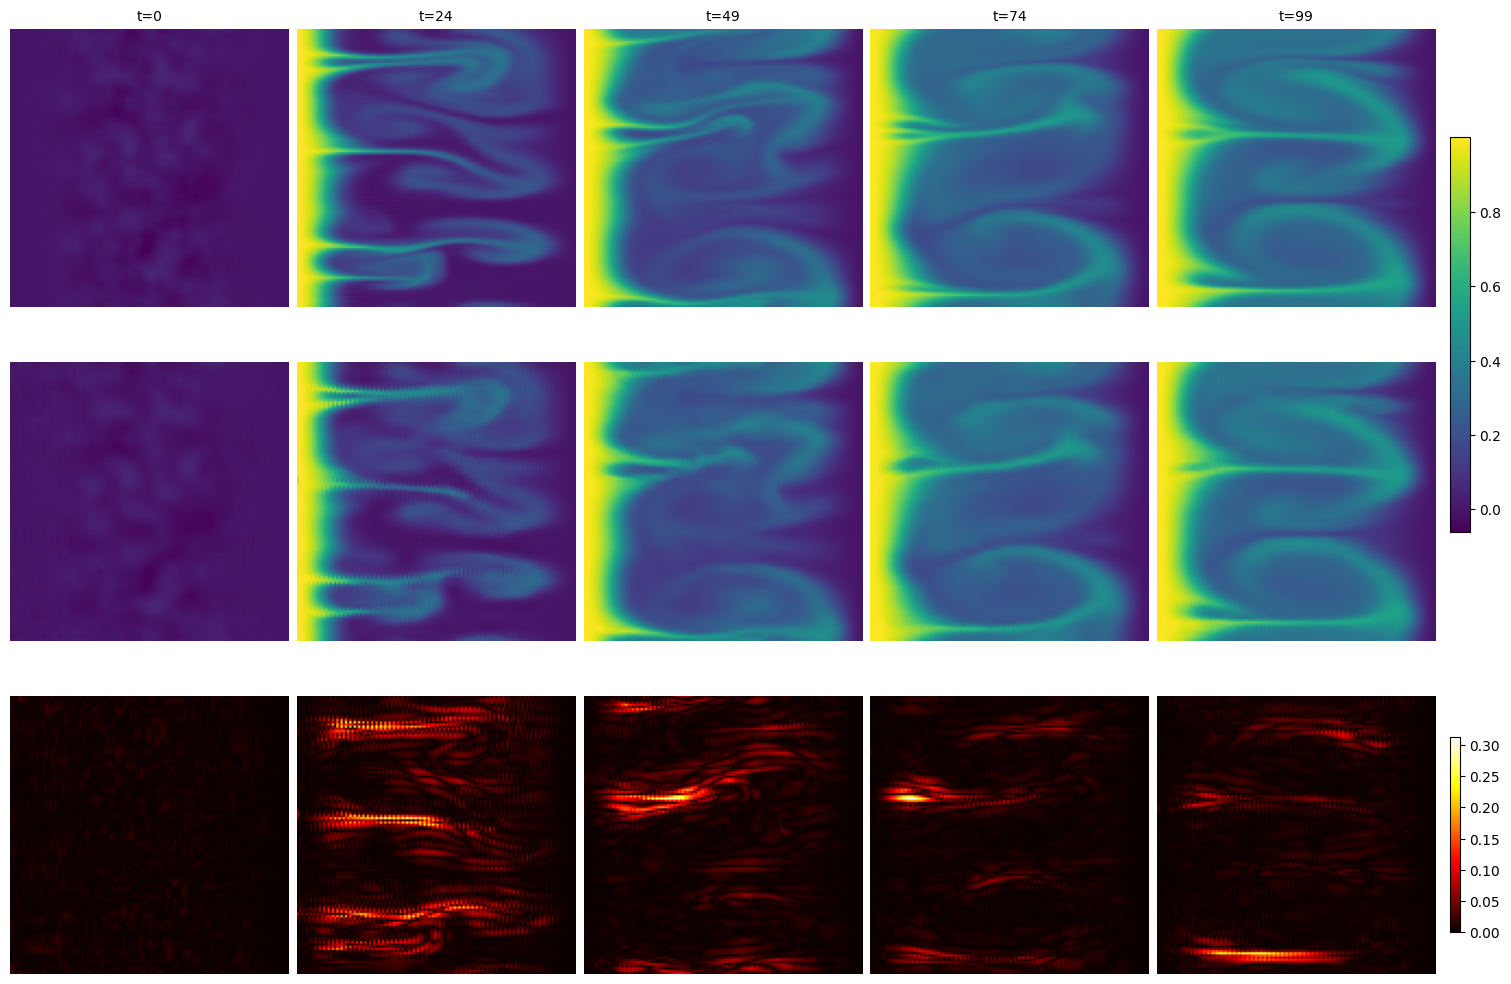

In [7]:
seq_id = 0   # which test sequence to visualise (0-indexed)

# Retrieve all frames belonging to this sequence
start = seq_id * frames_per_seq
end   = start + frames_per_seq

seq_x = dataset.test_dataset.x[start:end]   # (T, h, w, 1)
seq_y = dataset.test_dataset.y[start:end]   # (T, H, W, 1)

# Evenly sample 5 frame indices across the sequence
frame_indices = np.linspace(0, frames_per_seq - 1, 5, dtype=int).tolist()
print(f'Visualising frames: {frame_indices}')

forecaster.vis_video_sequence(
    seq_x, seq_y, normalizer,
    frame_indices=frame_indices,
    # save_path='vis_rb_seq0.png',   # uncomment to save
)